C:\Users\91797\AppData\Local\Temp\ipykernel_9336\2111136049.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\2111136049.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 46


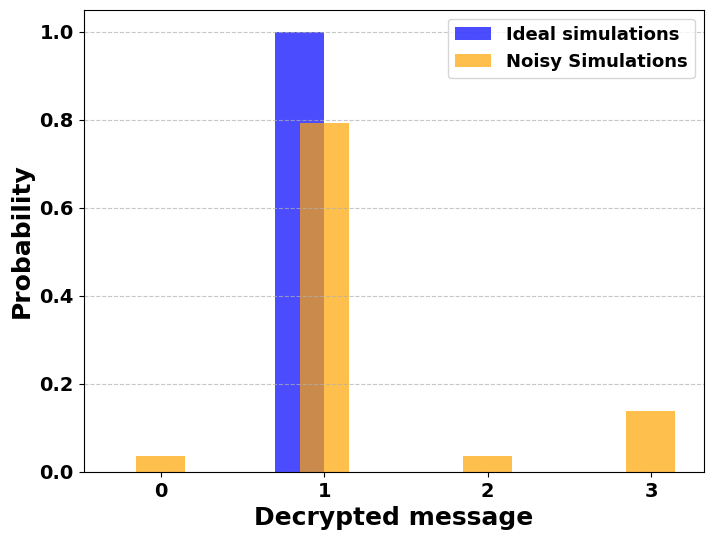

In [7]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M1l0.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\3369964901.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\3369964901.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 46


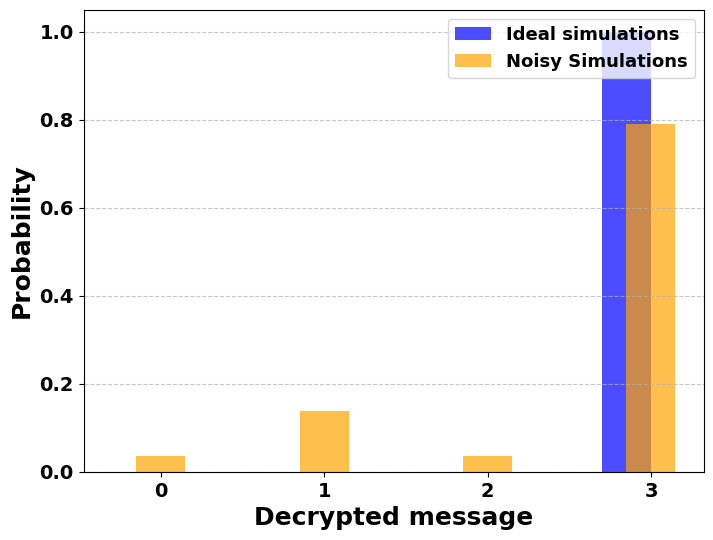

In [8]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(-np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M3l0.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1491856589.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1491856589.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 46


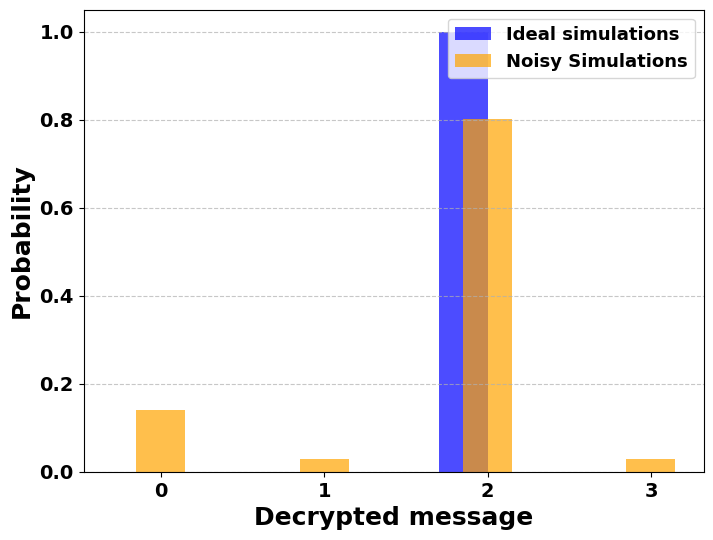

In [9]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
#qc.p(np.pi,3)
qc.z(4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M2l0.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1860831980.py:20: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1860831980.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 45


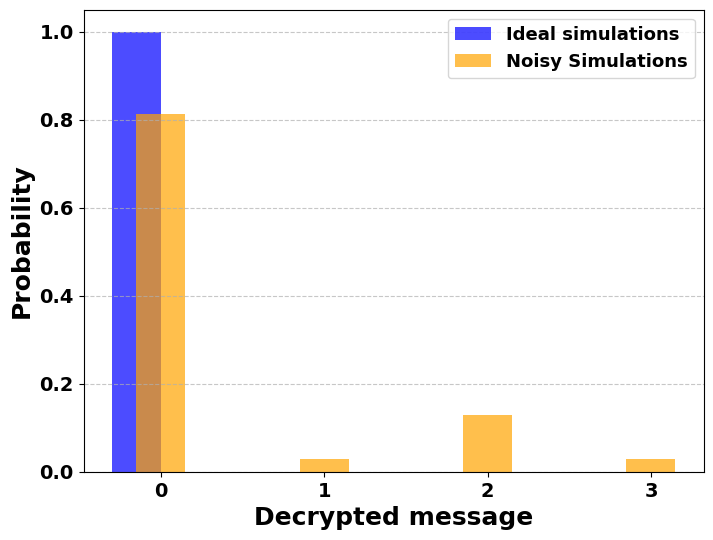

In [10]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
#qc.p(np.pi,3)
#qc.z(4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M0l0.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\2617479897.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\2617479897.py:50: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 47


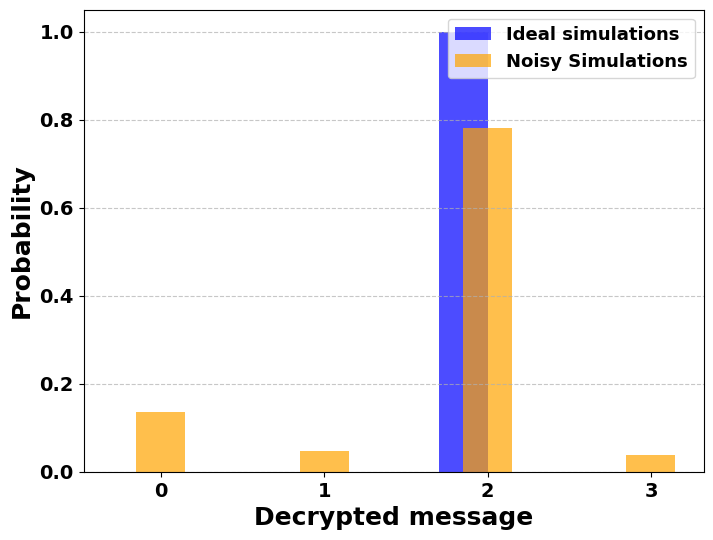

In [11]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.x(0)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M1l2.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1141305592.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1141305592.py:50: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 47


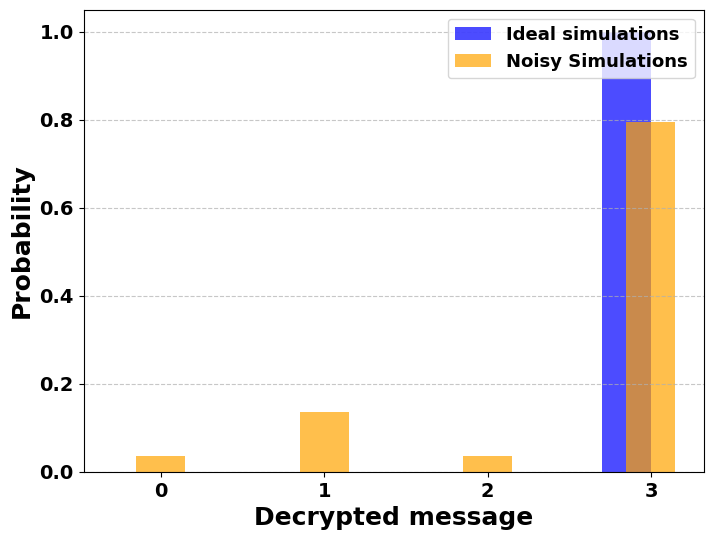

In [13]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.x(1)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M1l2.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1370629353.py:22: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1370629353.py:51: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this 

Depth in Aer : 47


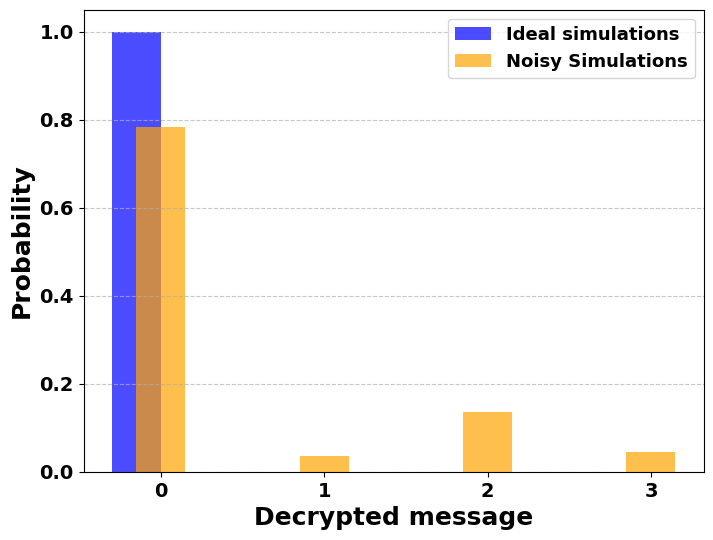

In [14]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.x(1)
qc.x(0)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M1l3.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\1182297807.py:22: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])


Depth in Aer : 7


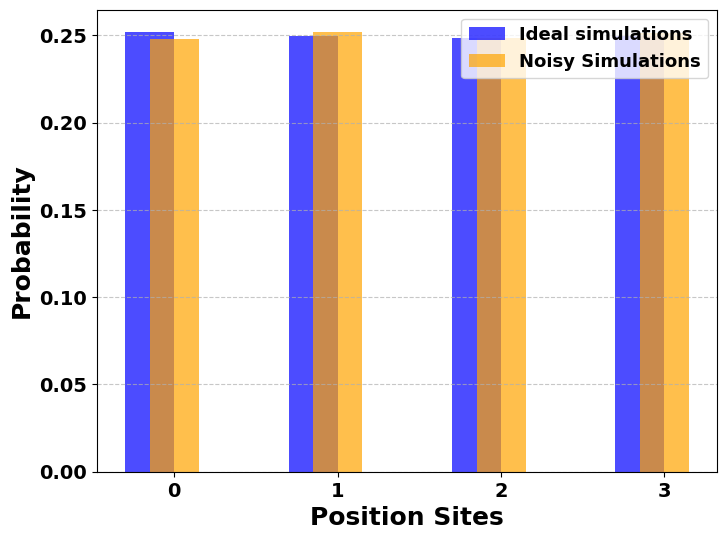

In [18]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.x(1)
qc.x(0)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)


qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Position Sites", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("Public Key.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_9336\3118646920.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_9336\3118646920.py:50: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])


Depth in Aer : 47


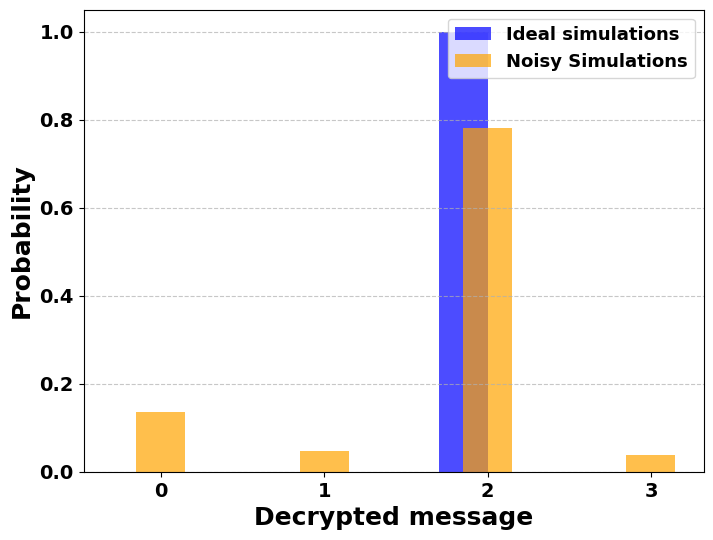

In [19]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

qc = QuantumCircuit(3, 2)
# Alice prepares the public key

qc = QuantumCircuit(6,6)
qc.x(0)
qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
plt.savefig("M1l11.png")
plt.show()




In [1]:
#Ancilla Register Trial

C:\Users\91797\AppData\Local\Temp\ipykernel_5536\94121655.py:39: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_5536\94121655.py:83: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this will

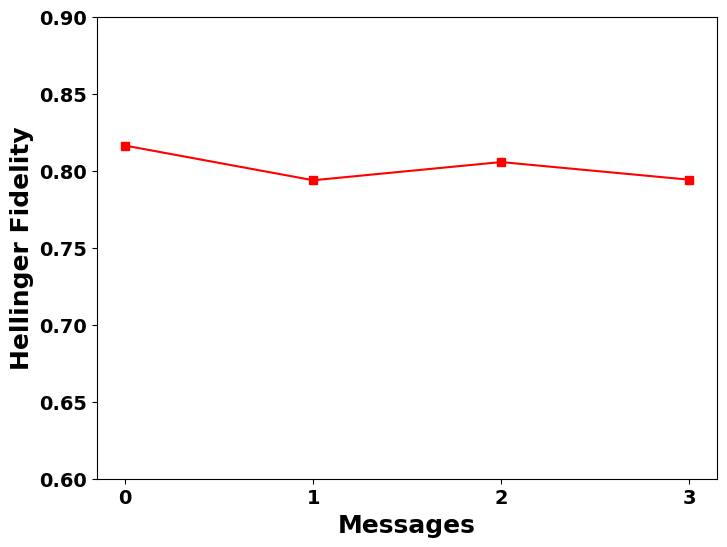

In [10]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

def hellinger_fidelity(prob_ideal, prob_noisy):
    # prob_ideal and prob_noisy are lists [p0,p1,p2,p3]
    h2 = 0.5 * sum((np.sqrt(prob_ideal[k]) - np.sqrt(prob_noisy[k]))**2 for k in range(len(prob_ideal)))
    H = (1 - h2)**2
    return H

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
# Alice prepares the public key
messages = [0,1,2,3]
hellinger_fidelity_all = []

for m in messages:
    qc = QuantumCircuit(6,6)
    qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
    for i in range(2):
        qc.append(B,[2])
        qc.p(-np.pi,0)
        qc.p(-np.pi/2,1)
        qc.cp(np.pi,2,1)
    

    qc.barrier()
    qc.swap(0, 3)
    qc.swap(1, 4)
    qc.swap(2, 5)
    qc.barrier()

    if m == 0:
        pass  # Identity on both qubits
    
    elif m == 1:
        qc.p(np.pi, 3)       # Z on qubit 3
        qc.p(np.pi/2, 4)     # P(pi/2) on qubit 4

    elif m == 2:
        qc.p(np.pi, 4)       # Z on qubit 4 only

    elif m == 3:
        qc.p(np.pi, 3)       # Z on qubit 3
        qc.p(-np.pi/2, 4)    
    qc.barrier()
    
    qc.swap(0, 3)
    qc.swap(1, 4)
    qc.swap(2, 5)
    qc.barrier()


    for j in range(18):
        
        if j % 4 == 0 or j % 4 == 1:
            qc.append(A,[2])
        else:
            qc.append(B,[2])
        qc.p(-np.pi,0)
        qc.p(-np.pi/2,1)
        qc.cp(np.pi,2,1)  
    qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
    qc.barrier()
    qc.measure([0,1],[0,1])


    qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)

    # IDEAL
    counts_ideal = simulator.run(qc_t, shots=shots).result().get_counts()

    # NOISY
    counts_noisy = simulator.run(
        qc_t, shots=shots, noise_model=noise_model, basis_gates=basis_gates
    ).result().get_counts()


    # ----------------------------------------------------------------
    # Convert to probability vectors
    # ----------------------------------------------------------------
    positions = [0,1,2,3]
    prob_ideal = {pos:0 for pos in positions}
    prob_noisy = {pos:0 for pos in positions}

    for state, cnt in counts_ideal.items():
        prob_ideal[int(state,2)] = cnt/shots

    for state, cnt in counts_noisy.items():
        prob_noisy[int(state,2)] = cnt/shots

    p_ideal = [prob_ideal[pos] for pos in positions]
    p_noisy = [prob_noisy[pos] for pos in positions]

    # ----------------------------------------------------------------
    # Compute Hellinger Fidelity for this message
    # ----------------------------------------------------------------
    H_m = hellinger_fidelity(p_ideal, p_noisy)
    hellinger_fidelity_all.append(H_m)



# ========================================================
# FINAL PLOT: Hellinger Fidelity vs Message
# ========================================================
plt.figure(figsize=(8,6))
plt.plot(messages, hellinger_fidelity_all, "s", linestyle = "-", color = "red")

plt.xlabel("Messages", fontsize=18, fontweight='bold')
plt.ylabel("Hellinger Fidelity", fontsize=18, fontweight='bold')
plt.xticks(messages, fontsize=14, fontweight='bold')
plt.yticks(fontsize=14, fontweight='bold')
plt.ylim(0.6,0.9)
#plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.title("Hellinger Fidelity vs Message", fontsize=18, fontweight='bold')
plt.savefig("HF.png")
plt.show()



C:\Users\91797\AppData\Local\Temp\ipykernel_30932\4204926405.py:75: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_30932\4204926405.py:127: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as th

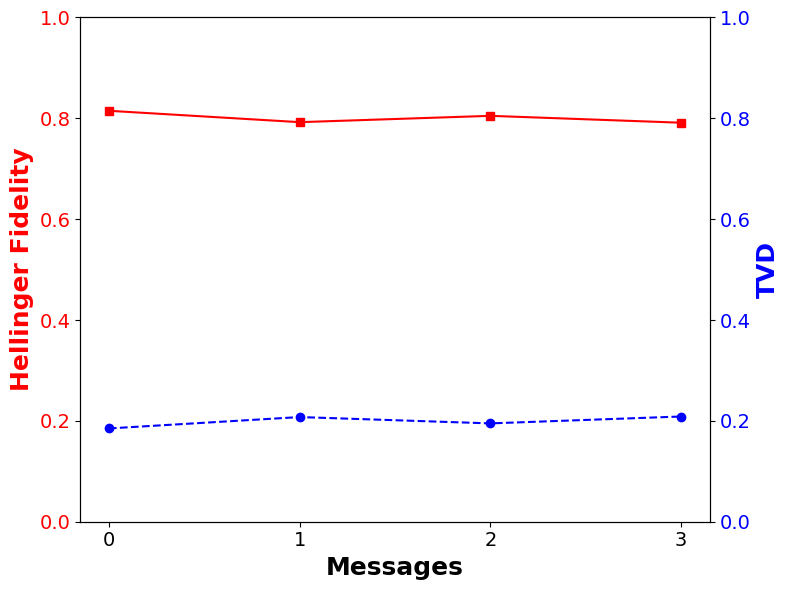

In [3]:
%matplotlib inline
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


# ===================================================================
# PARAMETERS
# ===================================================================
shots = 100000
p = 0.998489
q = 0.119545


# ===================================================================
# FUNCTIONS
# ===================================================================
def hellinger_fidelity(prob_ideal, prob_noisy):
    h2 = 0.5 * sum(
        (np.sqrt(prob_ideal[k]) - np.sqrt(prob_noisy[k]))**2
        for k in range(len(prob_ideal))
    )
    H = (1 - h2)**2
    return H

def tvd_distance(p, q):
    return 0.5 * sum(abs(p[i] - q[i]) for i in range(len(p)))


# ===================================================================
# UNITARIES
# ===================================================================
A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)],
                          [np.sqrt(1-p), -np.sqrt(p)]]), label='A')

B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)],
                          [np.sqrt(1-q), -np.sqrt(q)]]), label='B')


# ===================================================================
# NOISE MODEL
# ===================================================================
prob_noise = 0.03
prob_noise_1 = 0.03

error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])

basis_gates = noise_model.basis_gates

simulator = AerSimulator()


# ===================================================================
# MAIN LOOP OVER MESSAGES
# ===================================================================
messages = [0, 1, 2, 3]
hellinger_fidelity_all = []
TVD_all = []

for m in messages:

    # ---------------------------------------------------------------
    # BUILD CIRCUIT
    # ---------------------------------------------------------------
    qc = QuantumCircuit(6, 6)

    # Alice public key
    qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
    for i in range(2):
        qc.append(B, [2])
        qc.p(-np.pi, 0)
        qc.p(-np.pi/2, 1)
        qc.cp(np.pi, 2, 1)

    qc.barrier()

    # Bob receives key
    qc.swap(0, 3)
    qc.swap(1, 4)
    qc.swap(2, 5)

    qc.barrier()

    # ---------------------------------------------------------------
    # MESSAGE ENCODING
    # ---------------------------------------------------------------
    if m == 0:
        pass
    elif m == 1:
        qc.p(np.pi, 3)
        qc.p(np.pi/2, 4)
    elif m == 2:
        qc.p(np.pi, 4)
    elif m == 3:
        qc.p(np.pi, 3)
        qc.p(-np.pi/2, 4)

    qc.barrier()

    # Send back to Alice
    qc.swap(0, 3)
    qc.swap(1, 4)
    qc.swap(2, 5)

    qc.barrier()

    # ---------------------------------------------------------------
    # DECRYPTION
    # ---------------------------------------------------------------
    for j in range(18):
        if j % 4 in (0, 1):
            qc.append(A, [2])
        else:
            qc.append(B, [2])

        qc.p(-np.pi, 0)
        qc.p(-np.pi/2, 1)
        qc.cp(np.pi, 2, 1)

    qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])

    qc.measure([0, 1], [0, 1])

    # ---------------------------------------------------------------
    # TRANSPILATION
    # ---------------------------------------------------------------
    qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)

    # ---------------------------------------------------------------
    # RUN: IDEAL
    # ---------------------------------------------------------------
    counts_ideal = simulator.run(qc_t, shots=shots).result().get_counts()

    # ---------------------------------------------------------------
    # RUN: NOISY
    # ---------------------------------------------------------------
    counts_noisy = simulator.run(
        qc_t,
        shots=shots,
        noise_model=noise_model,
        basis_gates=basis_gates
    ).result().get_counts()

    # ---------------------------------------------------------------
    # GET PROBABILITY DISTRIBUTIONS
    # ---------------------------------------------------------------
    positions = [0,1,2,3]
    prob_ideal = {pos:0 for pos in positions}
    prob_noisy = {pos:0 for pos in positions}

    for state, cnt in counts_ideal.items():
        prob_ideal[int(state, 2)] = cnt / shots

    for state, cnt in counts_noisy.items():
        prob_noisy[int(state, 2)] = cnt / shots

    p_ideal = [prob_ideal[pos] for pos in positions]
    p_noisy = [prob_noisy[pos] for pos in positions]

    # ---------------------------------------------------------------
    # HELINGER FIDELITY
    # ---------------------------------------------------------------
    HF_m = hellinger_fidelity(p_ideal, p_noisy)
    hellinger_fidelity_all.append(HF_m)

    # ---------------------------------------------------------------
    # TOTAL VARIATION DISTANCE (TVD)
    # ---------------------------------------------------------------
    TVD_m = tvd_distance(p_ideal, p_noisy)
    TVD_all.append(TVD_m)



# ===================================================================
# FINAL DUAL-AXIS PLOT: HF (left) AND TVD (right)
# ===================================================================
fig, ax1 = plt.subplots(figsize=(8, 6))

# Left axis → HF
ax1.set_xlabel("Messages", fontsize=18, fontweight='bold')
ax1.set_ylabel("Hellinger Fidelity", fontsize=18, fontweight='bold', color="red")
ax1.plot(messages, hellinger_fidelity_all, "s-", color="red", label="HF")
ax1.tick_params(axis='y', labelcolor="red")
ax1.set_ylim(0, 1)

# Right axis → TVD
ax2 = ax1.twinx()
ax2.set_ylabel("TVD", fontsize=18, fontweight='bold', color="blue")
ax2.plot(messages, TVD_all, "o--", color="blue", label="TVD")
ax2.tick_params(axis='y', labelcolor="blue")
ax2.set_ylim(0,1)

ax1.set_xticks(messages)
ax1.tick_params(axis='both', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)

plt.tight_layout()
#plt.savefig("HF_TVD_dual_axis.png")
plt.show()


C:\Users\91797\AppData\Local\Temp\ipykernel_30932\95940200.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_30932\95940200.py:50: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this wi

Depth in Aer : 46


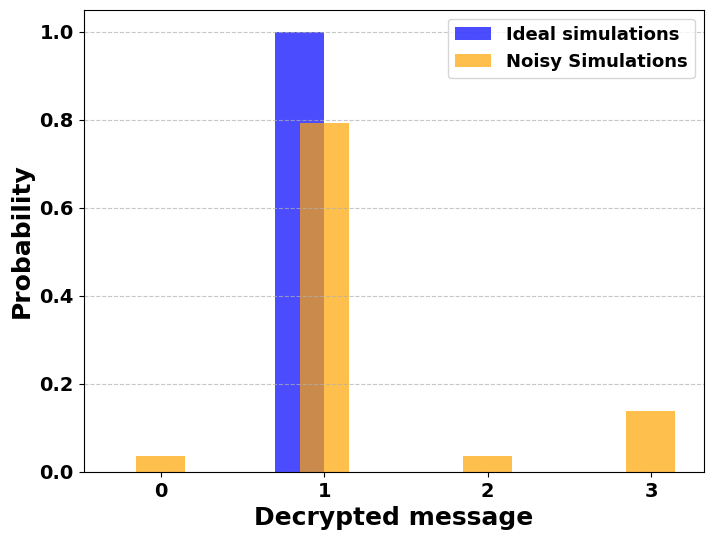

In [5]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 100000
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')


# Alice prepares the public key

qc = QuantumCircuit(6,6)

qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()
qc.p(np.pi,3)
qc.p(np.pi/2,4)
qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
#plt.savefig("M1l11.png")
plt.show()




C:\Users\91797\AppData\Local\Temp\ipykernel_30932\33034436.py:21: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
C:\Users\91797\AppData\Local\Temp\ipykernel_30932\33034436.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
C:\Users\91797\anaconda3\Lib\site-packages\qiskit\compiler\transpiler.py:269: UserWarning: Providing `coupling_map` and/or `basis_gates` along with `backend` is not recommended, as this wi

Depth in Aer : 45


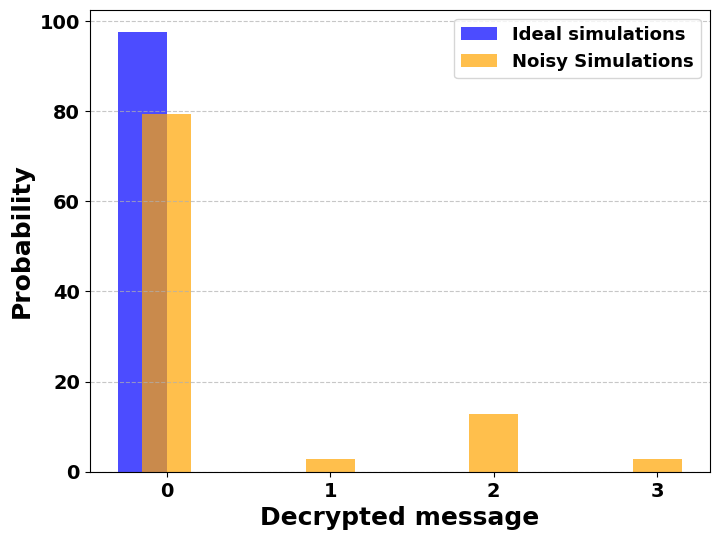

In [6]:
%matplotlib inline 
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator, noise
import numpy as np
import matplotlib.pyplot as plt
from qiskit.circuit.library import QFT, UnitaryGate


shots = 1024
p = 0.998489
q = 0.119545

A = UnitaryGate(np.array([[np.sqrt(p), np.sqrt(1-p)], [np.sqrt(1-p), -np.sqrt(p)]]), label='A')
B = UnitaryGate(np.array([[np.sqrt(q), np.sqrt(1-q)], [np.sqrt(1-q), -np.sqrt(q)]]), label='B')


# Alice prepares the public key

qc = QuantumCircuit(6,6)

qc.append(QFT(2, do_swaps=False).to_gate(label='QFT'), [0, 1])
for i in range(2):
    qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()

qc.barrier()
qc.swap(0, 3)
qc.swap(1, 4)
qc.swap(2, 5)
qc.barrier()


for j in range(18):
    if j % 4 == 0 or j % 4 == 1:
        qc.append(A,[2])
    else:
        qc.append(B,[2])
    qc.p(-np.pi,0)
    qc.p(-np.pi/2,1)
    qc.cp(np.pi,2,1)  
qc.append(QFT(2, do_swaps=False).inverse().to_gate(label='QFT'), [0, 1])
qc.barrier()
qc.measure([0,1],[0,1])

prob_noise = 0.03
prob_noise_1 = 0.03
error = noise.depolarizing_error(prob_noise, 2)
error_1 = noise.depolarizing_error(prob_noise_1, 1)
noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(error, ['cp'])
noise_model.add_all_qubit_quantum_error(error_1, ['u','h','p','z','x'])
basis_gates = noise_model.basis_gates

# Simulator
simulator = AerSimulator()
qc_t = transpile(qc, backend=simulator, basis_gates=basis_gates)


# Run simulations
result = simulator.run(qc_t, shots=100000).result()
counts = result.get_counts()
result_noisy = simulator.run(qc_t, shots=100000, noise_model=noise_model, basis_gates=basis_gates).result()
counts_noisy = result_noisy.get_counts()

positions = [0, 1, 2, 3]  
prob = {int(state, 2) % 4: count / shots for state, count in counts.items()}
prob_noisy = {int(state, 2) % 4: count / shots for state, count in counts_noisy.items()}
# Fill missing positions with 0 probability
prob = {pos: prob.get(pos, 0) for pos in positions}
prob_noisy = {pos: prob_noisy.get(pos, 0) for pos in positions}
# Convert data for plotting
prob_values = [prob[pos] for pos in positions]
prob_noisy_values = [prob_noisy[pos] for pos in positions]
# Plot
fig, ax = plt.subplots(figsize=(8, 6))
width = 0.3  # Bar width
ax.bar([p - width / 2 for p in positions], prob_values, width=width, color="blue", alpha=0.7, label="Ideal simulations")
ax.bar([p for p in positions], prob_noisy_values, width=width, color="orange", alpha=0.7, label="Noisy Simulations")
# Labels and formatting
ax.set_xlabel("Decrypted message", fontsize=18,fontweight= 'bold')
ax.set_ylabel("Probability", fontsize=18, fontweight = 'bold')
ax.set_xticks(positions)
plt.xticks(fontweight = 'bold', fontsize = 14)
plt.yticks(fontweight = 'bold', fontsize = 14)
ax.legend()
plt.legend(prop={'weight': 'bold','size':'13'},loc = 'upper right')
#ax.grid()
ax.grid(axis='y', linestyle='--', alpha=0.7)  # Dashed horizontal grid lines

#qc.draw('mpl')
print("Depth in Aer :",qc.depth())
#plt.savefig("M1l11.png")
plt.show()


